In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from IPython.display import display, Markdown

# Rerata dan Simpangan Baku dari Data Pengukuran

Diberikan data pengukuran

$$
x_i = 9, 5, 25, 23, 10, 22, 8, 8, 21, 20.
$$

Hitung rerata $\langle x\rangle$, momen kedua $\langle x^2\rangle$, variansi $\Delta x^2$, dan simpangan baku $\Delta x$.

Rumus yang digunakan adalah

$$
\langle x\rangle = \frac{1}{N}\sum_{i=1}^{N}x_i,
$$

$$
\langle x^2\rangle = \frac{1}{N}\sum_{i=1}^{N}x_i^2,
$$

$$
\Delta x^2 = \langle x^2\rangle - \langle x\rangle^2,
$$

dan

$$
\Delta x = \sqrt{\langle x^2\rangle - \langle x\rangle^2}.
$$

In [3]:
x = np.array([9, 5, 25, 23, 10, 22, 8, 8, 21, 20], dtype=float)
N = len(x)

mean_x = np.mean(x)
mean_x2 = np.mean(x**2)
var_x = mean_x2 - mean_x**2
std_x = np.sqrt(var_x)

print("Data x_i:", x.astype(int))
print("Jumlah data N:", N)
print()
print(f"<x>     = {mean_x:.1f}")
print(f"<x^2>   = {mean_x2:.1f}")
print(f"Delta x^2 = {var_x:.2f}")
print(f"Delta x   = {std_x:.1f}")
print()
print(f"Hasil pengukuran: x = {mean_x:.1f} ± {std_x:.1f}")

Data x_i: [ 9  5 25 23 10 22  8  8 21 20]
Jumlah data N: 10

<x>     = 15.1
<x^2>   = 281.3
Delta x^2 = 53.29
Delta x   = 7.3

Hasil pengukuran: x = 15.1 ± 7.3


# Histogram dan Distribusi Probabilitas

Gunakan data yang sama:

$$
x_i = 9, 5, 25, 23, 10, 22, 8, 8, 21, 20.
$$

Data dikelompokkan ke dalam kelas interval dengan titik tengah

$$
x_j = 6, 9, 12, 15, 18, 21, 24.
$$

Setiap kelas mewakili lebar interval 3. Probabilitas tiap kelas dihitung dengan

$$
P(x_j) = \frac{N(x_j)}{N}.
$$

Distribusi probabilitas harus ternormalisasi:

$$
\sum_j P(x_j) = 1.
$$

x_j      = [ 6  9 12 15 18 21 24]
N(x_j)   = [1 4 0 0 0 3 2]
P(x_j)   = [0.1 0.4 0.  0.  0.  0.3 0.2]
Jumlah P = 1.0


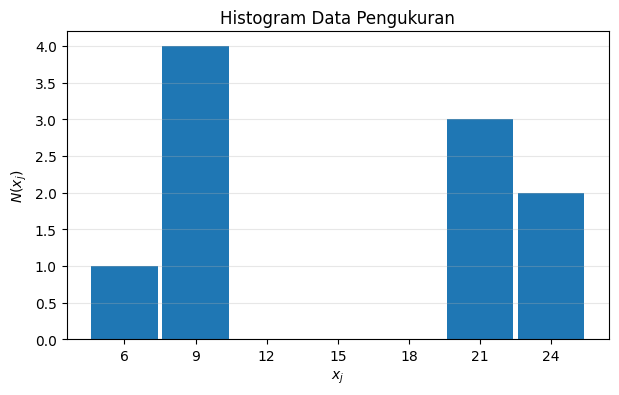

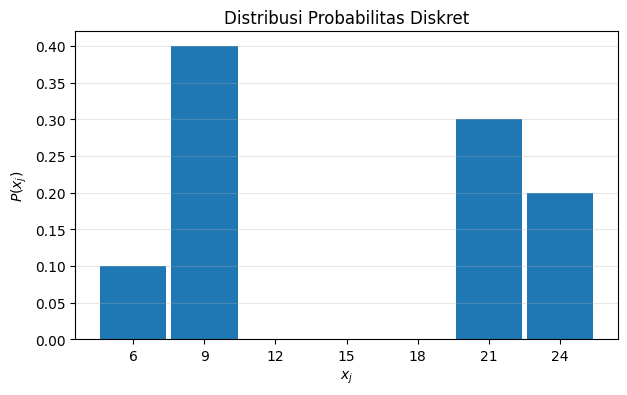

In [4]:
x = np.array([9, 5, 25, 23, 10, 22, 8, 8, 21, 20], dtype=float)
N = len(x)

# Kelas interval:
# 5, 6, 7 masuk ke kelas berlabel 6
# 8, 9, 10 masuk ke kelas berlabel 9
# 11, 12, 13 masuk ke kelas berlabel 12
# dan seterusnya.

bin_edges = np.array([4.5, 7.5, 10.5, 13.5, 16.5, 19.5, 22.5, 25.5])
xj = np.array([6, 9, 12, 15, 18, 21, 24], dtype=float)

counts, _ = np.histogram(x, bins=bin_edges)
prob = counts / N

print("x_j      =", xj.astype(int))
print("N(x_j)   =", counts)
print("P(x_j)   =", prob)
print("Jumlah P =", prob.sum())

plt.figure(figsize=(7, 4))
plt.bar(xj, counts, width=2.8)
plt.xlabel(r"$x_j$")
plt.ylabel(r"$N(x_j)$")
plt.title("Histogram Data Pengukuran")
plt.xticks(xj)
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(xj, prob, width=2.8)
plt.xlabel(r"$x_j$")
plt.ylabel(r"$P(x_j)$")
plt.title("Distribusi Probabilitas Diskret")
plt.xticks(xj)
plt.grid(axis="y", alpha=0.3)
plt.show()

# Rerata dan Simpangan Baku dari Distribusi Probabilitas

Jika distribusi probabilitas diskret $P(x_j)$ sudah diketahui, rerata dapat dihitung dengan

$$
\langle x\rangle = \sum_j x_j P(x_j).
$$

Momen kedua dihitung dengan

$$
\langle x^2\rangle = \sum_j x_j^2 P(x_j).
$$

Variansi dan simpangan baku kemudian diberikan oleh

$$
\Delta x^2 = \langle x^2\rangle - \langle x\rangle^2,
$$

dan

$$
\Delta x = \sqrt{\langle x^2\rangle - \langle x\rangle^2}.
$$

In [5]:
xj = np.array([6, 9, 12, 15, 18, 21, 24], dtype=float)
counts = np.array([1, 4, 0, 0, 0, 3, 2], dtype=float)
N = np.sum(counts)
prob = counts / N

mean_from_prob = np.sum(xj * prob)
mean_x2_from_prob = np.sum((xj**2) * prob)
var_from_prob = mean_x2_from_prob - mean_from_prob**2
std_from_prob = np.sqrt(var_from_prob)

print("Distribusi probabilitas:")
for x_val, n_val, p_val in zip(xj, counts, prob):
    print(f"x_j = {x_val:4.1f}, N(x_j) = {int(n_val)}, P(x_j) = {p_val:.2f}")

print()
print(f"<x>       = {mean_from_prob:.1f}")
print(f"<x^2>     = {mean_x2_from_prob:.1f}")
print(f"Delta x^2 = {var_from_prob:.2f}")
print(f"Delta x   = {std_from_prob:.1f}")

Distribusi probabilitas:
x_j =  6.0, N(x_j) = 1, P(x_j) = 0.10
x_j =  9.0, N(x_j) = 4, P(x_j) = 0.40
x_j = 12.0, N(x_j) = 0, P(x_j) = 0.00
x_j = 15.0, N(x_j) = 0, P(x_j) = 0.00
x_j = 18.0, N(x_j) = 0, P(x_j) = 0.00
x_j = 21.0, N(x_j) = 3, P(x_j) = 0.30
x_j = 24.0, N(x_j) = 2, P(x_j) = 0.20

<x>       = 15.3
<x^2>     = 283.5
Delta x^2 = 49.41
Delta x   = 7.0


# Contoh Data A, Perhitungan Langsung

Diberikan himpunan data

$$
A = 10, 13, 14, 14, 6, 8, 7, 9, 12, 14, 13, 11, 10, 7, 7.
$$

Hitung rerata dan variansi langsung dari data.

Rerata langsung dihitung dengan

$$
\langle x\rangle = \frac{1}{N}\sum_{i=1}^{N}x_i.
$$

Momen kedua dihitung dengan

$$
\langle x^2\rangle = \frac{1}{N}\sum_{i=1}^{N}x_i^2.
$$

Variansi dihitung dengan

$$
\Delta x^2 = \langle x^2\rangle - \langle x\rangle^2.
$$

In [6]:
A = np.array([10, 13, 14, 14, 6, 8, 7, 9, 12, 14, 13, 11, 10, 7, 7], dtype=float)
N_A = len(A)

mean_A = np.mean(A)
mean_A2 = np.mean(A**2)
var_A = mean_A2 - mean_A**2
std_A = np.sqrt(var_A)

print("Data A:", A.astype(int))
print("Jumlah data N:", N_A)
print()
print(f"<x>       = {mean_A:.4f}")
print(f"<x^2>     = {mean_A2:.4f}")
print(f"Delta x^2 = {var_A:.4f}")
print(f"Delta x   = {std_A:.4f}")

Data A: [10 13 14 14  6  8  7  9 12 14 13 11 10  7  7]
Jumlah data N: 15

<x>       = 10.3333
<x^2>     = 114.6000
Delta x^2 = 7.8222
Delta x   = 2.7968


# Histogram dan Distribusi Probabilitas Data A

Gunakan lima kelas interval dengan titik tengah

$$
x_1 = 5.5, \quad
x_2 = 7.5, \quad
x_3 = 9.5, \quad
x_4 = 11.5, \quad
x_5 = 13.5.
$$

Aturan pengelompokan data:

- $5$ dan $6$ masuk ke kelas $x_1 = 5.5$.
- $7$ dan $8$ masuk ke kelas $x_2 = 7.5$.
- $9$ dan $10$ masuk ke kelas $x_3 = 9.5$.
- $11$ dan $12$ masuk ke kelas $x_4 = 11.5$.
- $13$ dan $14$ masuk ke kelas $x_5 = 13.5$.

Probabilitas setiap kelas adalah

$$
P(x_j) = \frac{N(x_j)}{N}.
$$

x_j      = [ 5.5  7.5  9.5 11.5 13.5]
N(x_j)   = [1 4 3 2 5]
P(x_j)   = [0.06666667 0.26666667 0.2        0.13333333 0.33333333]
Jumlah P = 1.0


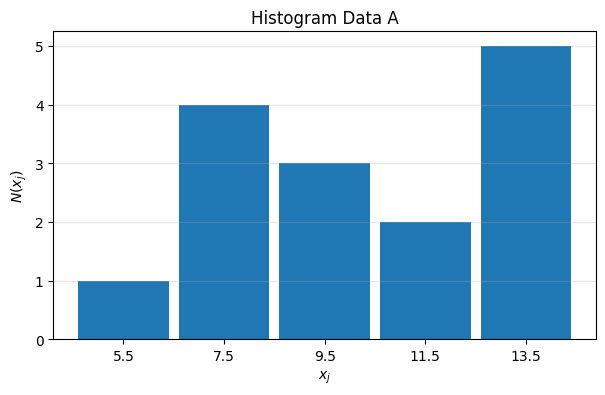

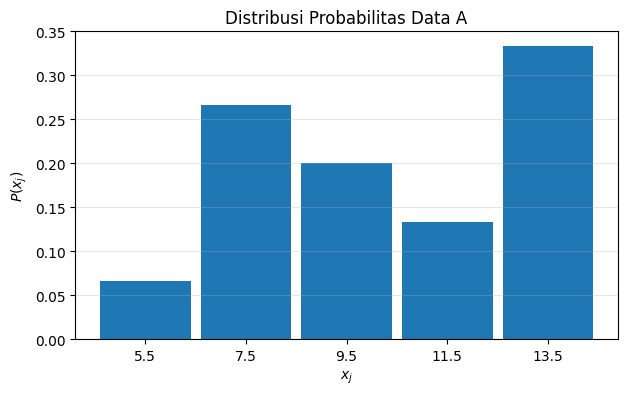

In [7]:
A = np.array([10, 13, 14, 14, 6, 8, 7, 9, 12, 14, 13, 11, 10, 7, 7], dtype=float)
N_A = len(A)

bin_edges_A = np.array([4.5, 6.5, 8.5, 10.5, 12.5, 14.5])
xj_A = np.array([5.5, 7.5, 9.5, 11.5, 13.5])

counts_A, _ = np.histogram(A, bins=bin_edges_A)
prob_A = counts_A / N_A

print("x_j      =", xj_A)
print("N(x_j)   =", counts_A)
print("P(x_j)   =", prob_A)
print("Jumlah P =", prob_A.sum())

plt.figure(figsize=(7, 4))
plt.bar(xj_A, counts_A, width=1.8)
plt.xlabel(r"$x_j$")
plt.ylabel(r"$N(x_j)$")
plt.title("Histogram Data A")
plt.xticks(xj_A)
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(xj_A, prob_A, width=1.8)
plt.xlabel(r"$x_j$")
plt.ylabel(r"$P(x_j)$")
plt.title("Distribusi Probabilitas Data A")
plt.xticks(xj_A)
plt.grid(axis="y", alpha=0.3)
plt.show()

# Rerata dan Variansi Data A dari Distribusi Probabilitas

Dari histogram Data A, rerata berdasarkan distribusi probabilitas dihitung dengan

$$
\langle x\rangle = \sum_{j=1}^{5}x_jP(x_j).
$$

Variansi dapat dihitung dengan dua formula berbeda.

Formula pertama:

$$
\Delta x^2 = \langle (x-\langle x\rangle)^2\rangle
= \sum_{j=1}^{5}(x_j-\langle x\rangle)^2P(x_j).
$$

Formula kedua:

$$
\Delta x^2 = \langle x^2\rangle - \langle x\rangle^2,
$$

dengan

$$
\langle x^2\rangle = \sum_{j=1}^{5}x_j^2P(x_j).
$$

In [8]:
xj_A = np.array([5.5, 7.5, 9.5, 11.5, 13.5])
counts_A = np.array([1, 4, 3, 2, 5], dtype=float)
N_A = np.sum(counts_A)
prob_A = counts_A / N_A

mean_A_prob = np.sum(xj_A * prob_A)

var_A_prob_1 = np.sum((xj_A - mean_A_prob)**2 * prob_A)

mean_A2_prob = np.sum((xj_A**2) * prob_A)
var_A_prob_2 = mean_A2_prob - mean_A_prob**2

print("Distribusi probabilitas Data A:")
for x_val, n_val, p_val in zip(xj_A, counts_A, prob_A):
    print(f"x_j = {x_val:4.1f}, N(x_j) = {int(n_val)}, P(x_j) = {p_val:.4f}")

print()
print(f"<x> dari distribusi probabilitas = {mean_A_prob:.4f}")
print()
print("Variansi dengan formula pertama:")
print(f"<(x - <x>)^2> = {var_A_prob_1:.4f}")
print()
print("Variansi dengan formula kedua:")
print(f"<x^2> - <x>^2 = {var_A_prob_2:.4f}")

Distribusi probabilitas Data A:
x_j =  5.5, N(x_j) = 1, P(x_j) = 0.0667
x_j =  7.5, N(x_j) = 4, P(x_j) = 0.2667
x_j =  9.5, N(x_j) = 3, P(x_j) = 0.2000
x_j = 11.5, N(x_j) = 2, P(x_j) = 0.1333
x_j = 13.5, N(x_j) = 5, P(x_j) = 0.3333

<x> dari distribusi probabilitas = 10.3000

Variansi dengan formula pertama:
<(x - <x>)^2> = 7.3600

Variansi dengan formula kedua:
<x^2> - <x>^2 = 7.3600


# Probabilitas Marginal, Gabungan, dan Kondisional

Diberikan data pasangan

$$
(x_i,y_i) =
(3,4), (5,8), (4,4), (8,5), (3,5), (4,5), (5,8),
(8,5), (8,4), (3,4), (3,8), (4,8).
$$

Tentukan probabilitas marginal $P(x)$ dan $P(y)$.

Kemudian tentukan

$$
P(x=5,y=8)
$$

dan

$$
P(x=5|y=8).
$$

Verifikasi hubungan

$$
P(x,y) = P(x|y)P(y)
$$

untuk $x=5$ dan $y=8$.

In [9]:
data_B = np.array([
    [3, 4],
    [5, 8],
    [4, 4],
    [8, 5],
    [3, 5],
    [4, 5],
    [5, 8],
    [8, 5],
    [8, 4],
    [3, 4],
    [3, 8],
    [4, 8],
], dtype=int)

x_B = data_B[:, 0]
y_B = data_B[:, 1]
N_B = len(data_B)

def probability_table(values):
    unique_values, counts = np.unique(values, return_counts=True)
    probabilities = counts / len(values)
    return unique_values, counts, probabilities

x_vals, x_counts, px = probability_table(x_B)
y_vals, y_counts, py = probability_table(y_B)

print("Probabilitas marginal P(x):")
for val, count, p in zip(x_vals, x_counts, px):
    print(f"P(x = {val}) = {count}/{N_B} = {Fraction(int(count), N_B)} = {p:.4f}")

print()
print("Probabilitas marginal P(y):")
for val, count, p in zip(y_vals, y_counts, py):
    print(f"P(y = {val}) = {count}/{N_B} = {Fraction(int(count), N_B)} = {p:.4f}")

count_x5_y8 = np.sum((x_B == 5) & (y_B == 8))
count_y8 = np.sum(y_B == 8)
count_x5_given_y8 = count_x5_y8

P_x5_y8 = count_x5_y8 / N_B
P_y8 = count_y8 / N_B
P_x5_given_y8 = count_x5_given_y8 / count_y8

print()
print("Probabilitas gabungan:")
print(f"P(x = 5, y = 8) = {count_x5_y8}/{N_B} = {Fraction(int(count_x5_y8), N_B)} = {P_x5_y8:.4f}")

print()
print("Probabilitas kondisional:")
print(f"P(x = 5 | y = 8) = {count_x5_given_y8}/{count_y8} = {Fraction(int(count_x5_given_y8), int(count_y8))} = {P_x5_given_y8:.4f}")

print()
print("Verifikasi:")
print(f"P(x = 5 | y = 8) P(y = 8) = {P_x5_given_y8:.4f} x {P_y8:.4f} = {P_x5_given_y8 * P_y8:.4f}")
print(f"P(x = 5, y = 8)          = {P_x5_y8:.4f}")

Probabilitas marginal P(x):
P(x = 3) = 4/12 = 1/3 = 0.3333
P(x = 4) = 3/12 = 1/4 = 0.2500
P(x = 5) = 2/12 = 1/6 = 0.1667
P(x = 8) = 3/12 = 1/4 = 0.2500

Probabilitas marginal P(y):
P(y = 4) = 4/12 = 1/3 = 0.3333
P(y = 5) = 4/12 = 1/3 = 0.3333
P(y = 8) = 4/12 = 1/3 = 0.3333

Probabilitas gabungan:
P(x = 5, y = 8) = 2/12 = 1/6 = 0.1667

Probabilitas kondisional:
P(x = 5 | y = 8) = 2/4 = 1/2 = 0.5000

Verifikasi:
P(x = 5 | y = 8) P(y = 8) = 0.5000 x 0.3333 = 0.1667
P(x = 5, y = 8)          = 0.1667


# Distribusi Eksponensial Kontinu

Diberikan kerapatan probabilitas

$$
p(x) =
\begin{cases}
c e^{-\alpha x}, & x \geq 0,\\
0, & x < 0,
\end{cases}
$$

dengan $\alpha > 0$.

Syarat normalisasi adalah

$$
\int_{0}^{\infty} c e^{-\alpha x}\,dx = 1.
$$

Karena

$$
\int_{0}^{\infty} e^{-\alpha x}\,dx = \frac{1}{\alpha},
$$

maka

$$
\frac{c}{\alpha} = 1.
$$

Jadi,

$$
c = \alpha.
$$

Distribusi ternormalisasi menjadi

$$
p(x) = \alpha e^{-\alpha x}, \quad x \geq 0.
$$

Rerata dan momen kedua adalah

$$
\langle x\rangle = \frac{1}{\alpha},
$$

dan

$$
\langle x^2\rangle = \frac{2}{\alpha^2}.
$$

Simpangan bakunya adalah

$$
\Delta x
= \sqrt{\langle x^2\rangle - \langle x\rangle^2}
= \frac{1}{\alpha}.
$$

alpha     = 2.0
c         = 2.0
<x>       = 0.5000
<x^2>     = 0.5000
Delta x^2 = 0.2500
Delta x   = 0.5000


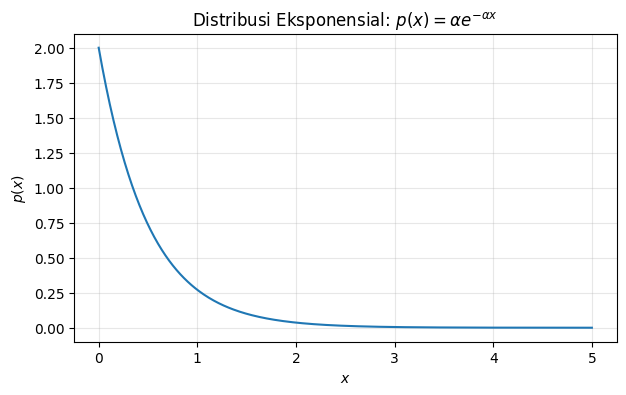

In [11]:
alpha = 2.0

c = alpha
mean_exp = 1 / alpha
mean_x2_exp = 2 / alpha**2
var_exp = mean_x2_exp - mean_exp**2
std_exp = np.sqrt(var_exp)

print(f"alpha     = {alpha}")
print(f"c         = {c}")
print(f"<x>       = {mean_exp:.4f}")
print(f"<x^2>     = {mean_x2_exp:.4f}")
print(f"Delta x^2 = {var_exp:.4f}")
print(f"Delta x   = {std_exp:.4f}")

x_grid = np.linspace(0, 5, 400)
p_exp = alpha * np.exp(-alpha * x_grid)

plt.figure(figsize=(7, 4))
plt.plot(x_grid, p_exp)
plt.xlabel(r"$x$")
plt.ylabel(r"$p(x)$")
plt.title(r"Distribusi Eksponensial: $p(x)=\alpha e^{-\alpha x}$")
plt.grid(alpha=0.3)
plt.show()

# Distribusi Gaussian

Diberikan kerapatan probabilitas ternormalisasi

$$
p(x)
=
\frac{1}{\beta\sqrt{\pi}}
e^{-(x-\alpha)^2/\beta^2},
$$

dengan $\alpha > 0$ dan $\beta > 0$.

Distribusi ini memiliki domain

$$
x \in (-\infty,\infty).
$$

Reratanya adalah

$$
\langle x\rangle = \alpha.
$$

Momen keduanya adalah

$$
\langle x^2\rangle = \alpha^2 + \frac{\beta^2}{2}.
$$

Simpangan bakunya adalah

$$
\Delta x
=
\sqrt{\langle x^2\rangle - \langle x\rangle^2}
=
\frac{\beta}{\sqrt{2}}.
$$

alpha     = 3.0
beta      = 2.0
<x>       = 3.0000
<x^2>     = 11.0000
Delta x^2 = 2.0000
Delta x   = 1.4142


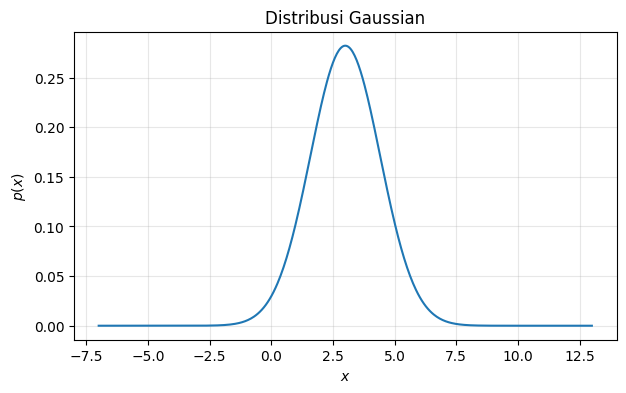

In [12]:
alpha = 3.0
beta = 2.0

mean_gauss = alpha
mean_x2_gauss = alpha**2 + beta**2 / 2
var_gauss = mean_x2_gauss - mean_gauss**2
std_gauss = beta / np.sqrt(2)

print(f"alpha     = {alpha}")
print(f"beta      = {beta}")
print(f"<x>       = {mean_gauss:.4f}")
print(f"<x^2>     = {mean_x2_gauss:.4f}")
print(f"Delta x^2 = {var_gauss:.4f}")
print(f"Delta x   = {std_gauss:.4f}")

x_grid = np.linspace(alpha - 5 * beta, alpha + 5 * beta, 500)
p_gauss = (1 / (beta * np.sqrt(np.pi))) * np.exp(-((x_grid - alpha)**2) / beta**2)

plt.figure(figsize=(7, 4))
plt.plot(x_grid, p_gauss)
plt.xlabel(r"$x$")
plt.ylabel(r"$p(x)$")
plt.title("Distribusi Gaussian")
plt.grid(alpha=0.3)
plt.show()

# Rangkuman Materi dan Formula Penting

## Data Diskret Langsung

Rerata:

$$
\langle x\rangle = \frac{1}{N}\sum_{i=1}^{N}x_i.
$$

Momen orde ke-$n$:

$$
\langle x^n\rangle = \frac{1}{N}\sum_{i=1}^{N}x_i^n.
$$

Deviasi:

$$
\delta x = x - \langle x\rangle.
$$

Rerata deviasi:

$$
\langle \delta x\rangle = 0.
$$

Variansi:

$$
\Delta x^2
=
\langle (\delta x)^2\rangle
=
\langle x^2\rangle - \langle x\rangle^2.
$$

Simpangan baku:

$$
\Delta x
=
\sqrt{\langle x^2\rangle - \langle x\rangle^2}.
$$

## Distribusi Probabilitas Diskret

Probabilitas dari histogram:

$$
P(x_j) = \frac{N(x_j)}{N}.
$$

Normalisasi:

$$
\sum_{j=1}^{M}P(x_j) = 1.
$$

Rerata fungsi $f(x)$:

$$
\langle f(x)\rangle
=
\sum_{j=1}^{M}f(x_j)P(x_j).
$$

## Distribusi Probabilitas Kontinu

Normalisasi:

$$
\int_{-\infty}^{\infty}p(x)\,dx = 1.
$$

Rerata:

$$
\langle x\rangle
=
\int_{-\infty}^{\infty}x p(x)\,dx.
$$

Rerata fungsi $f(x)$:

$$
\langle f(x)\rangle
=
\int_{-\infty}^{\infty}f(x)p(x)\,dx.
$$

## Probabilitas Gabungan dan Kondisional

Probabilitas marginal:

$$
p(x)
=
\int_{-\infty}^{\infty}p(x,y)\,dy.
$$

Rerata fungsi dua variabel:

$$
\langle f(x,y)\rangle
=
\int_{-\infty}^{\infty}
\int_{-\infty}^{\infty}
f(x,y)p(x,y)\,dx\,dy.
$$

Hubungan probabilitas gabungan dan kondisional:

$$
P(x,y) = P(x|y)P(y).
$$